In [1]:
import tensorflow.compat.v1 as tf

tf.config.set_soft_device_placement(True)
# tf.debugging.set_log_device_placement(True)
# from sklearn.metrics import confusion_matrix
import numpy as np
# from scipy.io import loadmat
import os
# from functools import reduce
# from scipy import signal
import pandas as pd
# from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow import keras as K
from tensorflow.keras.layers import Add, Dense, Activation, Flatten, concatenate, Input, Dropout, LSTM, Conv2D, MaxPooling2D, Conv1D, MaxPooling1D, BatchNormalization, PReLU, ELU, ReLU
from tensorflow.keras.models import Sequential, Model, load_model
import matplotlib.pyplot as plt
# import datetime
# get_ipython().run_line_magic('load_ext', 'tensorboard')
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# get_ipython().run_line_magic('matplotlib', 'inline')
# from collections import Counter 
np_load_old = np.load
# from tensorflow.keras.utils import plot_model
from tensorflow.keras.initializers import glorot_uniform
# modify the default parameters of np.load
np.load = lambda *a,**k: np_load_old(*a, allow_pickle=True, **k)
np.random.seed(42)
tf.set_random_seed(42)
from sklearn.metrics import classification_report
import argparse
import h5py

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import itertools

I0000 00:00:1774208963.624839   83116 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    plt.figure(figsize=(15,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=36)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=30)
    plt.yticks(tick_marks, classes, fontsize=30)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black", fontsize=28)

    plt.tight_layout()
    plt.ylabel('True label', fontsize=30)
    plt.xlabel('Predicted label', fontsize=30)

## Load in data

In [3]:
# load windowed-train dataset + fixed-window validation/test datasets
loadPath = '/home/sz4544/EEG-motor-imagery-main/project/'
os.makedirs(os.path.join(loadPath, "models"), exist_ok=True)

bestModel = '/home/sz4544/EEG-motor-imagery-main/project/models/baseline_tr1800_window512s128_val360_window512_ts_2CNN.keras'

f_train = h5py.File(os.path.join(loadPath, "train1800_window512s128_raw_EEG.h5"), "r")
tr_data = f_train['data'][:]
ytr = f_train['tasks'][:]
tr_subjects = f_train['subjects'][:]
f_train.close()

f_valid = h5py.File(os.path.join(loadPath, "valid360_window512_raw_EEG.h5"), "r")
val_data = f_valid['data'][:]
yval = f_valid['tasks'][:]
val_subjects = f_valid['subjects'][:]
f_valid.close()

f_test = h5py.File(os.path.join(loadPath, "test360_window512_raw_EEG.h5"), "r")
ts_data = f_test['data'][:]
yts = f_test['tasks'][:]
ts_subjects = f_test['subjects'][:]
f_test.close()

print("train:", tr_data.shape, ytr.shape)
print("valid:", val_data.shape, yval.shape)
print("test:", ts_data.shape, yts.shape)

print("train labels:", np.unique(ytr, return_counts=True))
print("valid labels:", np.unique(yval, return_counts=True))
print("test labels:", np.unique(yts, return_counts=True))

train: (3600, 512, 64) (3600,)
valid: (360, 512, 64) (360,)
test: (360, 512, 64) (360,)
train labels: (array([1., 2., 3., 4.]), array([900, 900, 900, 900]))
valid labels: (array([1., 2., 3., 4.]), array([90, 90, 90, 90]))
test labels: (array([1., 2., 3., 4.]), array([90, 90, 90, 90]))


## Normalization

In [4]:
# flatten and reshape data
xtr_s_flattened = np.squeeze(tr_data).ravel().reshape((-1, 64))
xval_s_flattened = np.squeeze(val_data).ravel().reshape((-1, 64))
xts_s_flattened = np.squeeze(ts_data).ravel().reshape((-1, 64))
print(xtr_s_flattened.shape)
print(xval_s_flattened.shape)
print(xts_s_flattened.shape)

# normalize data
scaler = StandardScaler()
Ztr_temp = scaler.fit_transform(xtr_s_flattened)
Zval_temp = scaler.transform(xval_s_flattened)
Zts_temp = scaler.transform(xts_s_flattened)

# reshape back
# reshape back
Ztr = np.squeeze(Ztr_temp).ravel().reshape((-1, 512, 64))
Zval = np.squeeze(Zval_temp).ravel().reshape((-1, 512, 64))
Zts = np.squeeze(Zts_temp).ravel().reshape((-1, 512, 64))

print("Ztr:", Ztr.shape)
print("Zval:", Zval.shape)
print("Zts:", Zts.shape)

(1843200, 64)
(184320, 64)
(184320, 64)
Ztr: (3600, 512, 64)
Zval: (360, 512, 64)
Zts: (360, 512, 64)


In [5]:
# remap labels to 0,1,2,3 if needed
ytr = ytr.astype(np.int64)
yval = yval.astype(np.int64)
yts = yts.astype(np.int64)

if np.array_equal(np.unique(ytr), np.array([1, 2, 3, 4])):
    ytr = ytr - 1
if np.array_equal(np.unique(yval), np.array([1, 2, 3, 4])):
    yval = yval - 1
if np.array_equal(np.unique(yts), np.array([1, 2, 3, 4])):
    yts = yts - 1

x_train = Ztr[..., np.newaxis]
x_valid = Zval[..., np.newaxis]
x_test = Zts[..., np.newaxis]

y_train = pd.get_dummies(ytr).values.astype(np.float32)
y_valid = pd.get_dummies(yval).values.astype(np.float32)
y_test = pd.get_dummies(yts).values.astype(np.float32)

print("x_train:", x_train.shape, x_train.dtype)
print("x_valid:", x_valid.shape, x_valid.dtype)
print("x_test:", x_test.shape, x_test.dtype)

print("y_train:", y_train.shape, y_train.dtype)
print("y_valid:", y_valid.shape, y_valid.dtype)
print("y_test:", y_test.shape, y_test.dtype)

x_train: (3600, 512, 64, 1) float64
x_valid: (360, 512, 64, 1) float64
x_test: (360, 512, 64, 1) float64
y_train: (3600, 4) float32
y_valid: (360, 4) float32
y_test: (360, 4) float32


## Model architecture

In [6]:
strategy = tf.distribute.MirroredStrategy()
print('Number of devices: {}'.format(strategy.num_replicas_in_sync))

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1774208966.666731   83116 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22272 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1774208966.667316   83116 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22253 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:61:00.0, compute capability: 8.9


Number of devices: 2


In [7]:
with strategy.scope():
    nodes = 512
    inputs = Input(shape=(nodes, 64, 1))

    conv1 = Conv2D(8, (15,9), strides=(2,1), kernel_initializer = glorot_uniform(seed=42))(inputs)
    batch1 = BatchNormalization()(conv1)
    prelu1 = PReLU()(batch1)
    maxpool1 = MaxPooling2D((2,2))(prelu1)
    conv2 = Conv2D(16, (15,9), strides=(2,1), kernel_initializer = glorot_uniform(seed=42))(maxpool1)
    batch2 = BatchNormalization()(conv2)
    prelu2 = PReLU()(batch2)
    # maxpool2 = MaxPooling2D((5,1))(prelu2)

    flat = Flatten()(prelu2)
    dense1 = Dense(16, activation='sigmoid', kernel_initializer = glorot_uniform(seed=42))(flat)
    drop1 = Dropout(0.2)(dense1)
    predictions = Dense(4, activation='softmax', kernel_initializer = glorot_uniform(seed=42))(drop1)
    model = Model(inputs=inputs,outputs=predictions)
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512, 64, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 249, 56, 8)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 249, 56, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu (PReLU)                 │ (None, 249, 56, 8)     │       111,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 28, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 55, 20, 16)     │        17,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 55, 20, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_1 (PReLU)               │ (None, 55, 20, 16)     │        17,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 17600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │       281,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,316 (1.64 MB)

 Trainable params: 429,268 (1.64 MB)

 Non-trainable params: 48 (192.00 B)

None


In [8]:
with strategy.scope():
    opt_adam = K.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
    model.compile(loss='categorical_crossentropy', optimizer=opt_adam, metrics=['categorical_accuracy'])

es = EarlyStopping(monitor='val_categorical_accuracy', mode='max', verbose=1, patience=30)
mc = ModelCheckpoint(bestModel, monitor='val_categorical_accuracy', mode='max', verbose=1, save_best_only=True)

In [9]:
history = model.fit(x=x_train, y=y_train, epochs=300, shuffle=True,
                    verbose=1, validation_data = (x_valid, y_valid), callbacks=[es, mc])

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1774208968.803568   83116 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


INFO:tensorflow:Collective all_reduce tensors: 14 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


I0000 00:00:1774208970.087643   83264 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1774208970.092860   83267 cuda_dnn.cc:461] Loaded cuDNN version 91002


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.2936 - loss: 1.4128INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_categorical_accuracy improved from None to 0.32222, saving model to /home/sz4544/EEG-motor-imagery-main/project/models/baseline_tr1800_window512s128_val360_window512_ts_2CNN.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - categorical_accuracy: 0.2931 - loss: 1.3918 - val_categorical_accuracy: 0.3222 - val_loss: 1.3639
Epoch 2/300
108/113 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.3482 - loss: 1.3304
Epoch 2: val_categorical_accuracy improved from 0.32222 to 0.33889, saving model to /home/sz4544/EEG-motor-imagery-main/project/models/baseline_tr1800_window512s128_val360_window512_ts_2CNN.keras
113

## Model testing

In [10]:
best_model = tf.keras.models.load_model(bestModel)
yhat = np.argmax(best_model.predict(x_test), axis=1)
ytrue = np.argmax(y_test, axis=1)
print('test acc: {:.2f}%'.format(np.sum(yhat == ytrue) / yts.shape[0] * 100))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
test acc: 38.06%


In [11]:
target_names = ['open one hand', 'imagine open one hand', 'open both hands/feet', 'imagine open both hands/feet']
print(classification_report(ytrue, yhat, target_names=target_names, digits=4))

                              precision    recall  f1-score   support

               open one hand     0.4091    0.4000    0.4045        90
       imagine open one hand     0.3708    0.3667    0.3687        90
        open both hands/feet     0.3803    0.3000    0.3354        90
imagine open both hands/feet     0.3661    0.4556    0.4059        90

                    accuracy                         0.3806       360
                   macro avg     0.3816    0.3806    0.3786       360
                weighted avg     0.3816    0.3806    0.3786       360



In [12]:
cm = confusion_matrix(ytrue, yhat)
cm

array([[36, 19, 16, 19],
       [15, 33, 14, 28],
       [28, 11, 27, 24],
       [ 9, 26, 14, 41]])

Normalized confusion matrix
[[0.4        0.21111111 0.17777778 0.21111111]
 [0.16666667 0.36666667 0.15555556 0.31111111]
 [0.31111111 0.12222222 0.3        0.26666667]
 [0.1        0.28888889 0.15555556 0.45555556]]


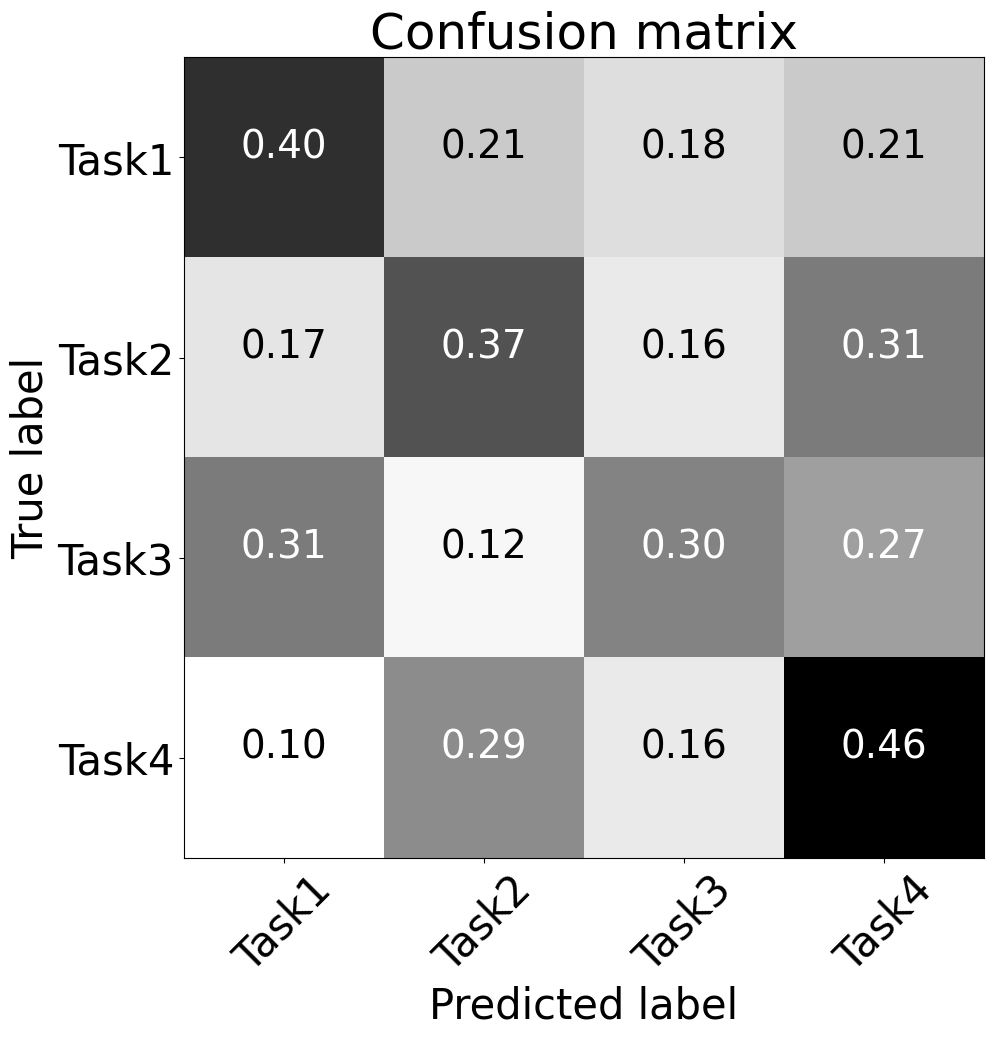

In [13]:
plot_confusion_matrix(cm, ['Task1', 'Task2', 'Task3', 'Task4'], normalize=True, title='Confusion matrix', cmap=plt.cm.Greys)